# Titanic — KNN validation curve over k

Part of my daily ML practice: one dataset, one question, one notebook.

Picking k by validation curve instead of guessing.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1287

rng = np.random.RandomState(SEED)
n = 1500
pclass = rng.choice([1, 2, 3], size=n, p=[0.20, 0.30, 0.50])
sex = rng.choice(["male", "female"], size=n, p=[0.62, 0.38])
age = np.clip(rng.normal(32, 14, size=n), 1, 80).round(1)
age[rng.rand(n) < 0.10] = np.nan                      # some missing ages
sibsp = np.clip(rng.poisson(0.6, size=n), 0, 5)
parch = np.clip(rng.poisson(0.4, size=n), 0, 4)
fare = np.clip(rng.lognormal(3.0 - 0.45 * (pclass - 1), 0.85, size=n), 5, 320).round(2)
embarked = rng.choice(["S", "C", "Q"], size=n, p=[0.72, 0.19, 0.09])
logit = (2.2 * (sex == "female") - 1.0 * (pclass == 3) - 0.45 * (pclass == 2)
         - 0.02 * (np.nan_to_num(age, nan=32) - 30) + 0.004 * fare
         + 0.4 * ((sibsp + parch) > 0) - 1.0)
survived = (rng.rand(n) < 1 / (1 + np.exp(-logit))).astype(int)
df = pd.DataFrame({"Pclass": pclass, "Sex": sex, "Age": age, "SibSp": sibsp,
                   "Parch": parch, "Fare": fare, "Embarked": embarked,
                   "Survived": survived})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nsurvival rate: %.3f" % df["Survived"].mean())
print("missing values:\n", df.isna().sum()[df.isna().sum() > 0])


shape: (1500, 8)
   Pclass     Sex   Age  SibSp  Parch  Fare Embarked  Survived
0       2    male  30.6      1      3  6.99        S         1
1       2  female  42.3      2      0  5.00        S         1
2       3  female  34.9      1      0  5.11        S         1

survival rate: 0.391
missing values:
 Age    145
dtype: int64


## Validation curve

best k: 27 (val accuracy 0.7280)


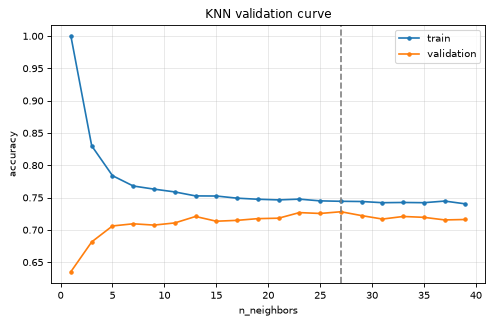

In [ ]:
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Pclass', 'Sex', 'Embarked']
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

X = df.drop(columns=["Survived"]); y = df["Survived"]
pipe = Pipeline([("prep", preprocess),
                 ("model", KNeighborsClassifier())])
k_range = np.arange(1, 40, 2)
train_s, val_s = validation_curve(pipe, X, y, param_name="model__n_neighbors",
                                  param_range=k_range, cv=5, scoring="accuracy", n_jobs=1)
tr_m, va_m = train_s.mean(1), val_s.mean(1)
best_k = int(k_range[np.argmax(va_m)])
print(f"best k: {best_k} (val accuracy {va_m.max():.4f})")
fig, ax = plt.subplots()
ax.plot(k_range, tr_m, marker="o", ms=3, label="train")
ax.plot(k_range, va_m, marker="o", ms=3, label="validation")
ax.axvline(best_k, ls="--", c="gray")
ax.set_xlabel("n_neighbors"); ax.set_ylabel("accuracy")
ax.set_title("KNN validation curve"); ax.legend()


## Takeaways

- Classic bias/variance shape: k=1 overfits, large k underfits.
- KNN lands below the tree models — distance in this mixed feature space is just not that informative.